# Combined CTR Simulation Workflow

This notebook calculates CTR produced from a finite, tilted interface for three different electron spatial distributions: Gaussian, Hollow Gaussian, and Airy.

**Organization**
1. Imports and physical constants
2. Beam/electron/radiator parameters
3. Observation grid
4. Single electron tilted interface transition radiation
5. Beam density models and profile plots
6. 2D/3D form factors
7. Bunch CTR spectrum
8. Longitudinal coherence calculations
9. Optional finite-radiator diagnostic

All shared quantities are defined once. The 3D Gaussian/hollow grids and the 2D Airy grid use distinct variable names.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import LogNorm
from scipy.interpolate import RegularGridInterpolator, interp1d
from scipy.special import airy, j0, j1, k0, k1

## 1. Physical constants and simulation parameters

In [2]:
# Physical constants
c = 299792458.0
e = 1.60217663e-19
h = 6.62607015e-34
eps0 = 8.854187812e-12
m_e_MeV = 0.51099895


# Electron-beam parameters
E_MeV = 100.0                    #kinetic energy [MeV]
bunchcharge = 5e-12              #bunch charge [C]
sigma_x = 100e-6                 #transverse rms scale [m]
sigma_y = 100e-6                 #transverse rms scale [m]
sigma_t = 1e-15                  #temporal rms scale [s]
sigma_z = c * sigma_t            #longitudinal rms scale [m]

#Hollow-Gaussian parameter
p_hollow = 3

#Finite-energy Airy parameters
airy_apodization = 0.05
z_prop = 10e6                    #Airy propagation coordinate [m]

#Interface parameters
psi = np.deg2rad(45.0)           #interface tilt
interface_radius = 1e-3          #finite radiator radius [m]

#Select which bunch to use for the CTR calculation: "gaussian", "hollow", or "airy"
beam_case = "airy"


In [3]:
# Derived relativistic quantities
E_total_MeV = E_MeV + m_e_MeV
gamma = E_total_MeV/m_e_MeV
beta = np.sqrt(1.0 - 1.0/gamma**2)
v = beta * c
Ne = bunchcharge/e

# Relativistic de Broglie wavelength used by the Airy model
E_kin_J = E_MeV*1e6*e
mc2_J = m_e_MeV*1e6*e
pc_J = np.sqrt(E_kin_J * (E_kin_J + 2.0*mc2_J))
lambda_e = h * c/pc_J
k_B = 2.0 * np.pi/lambda_e

print(f"gamma = {gamma:.6f}")
print(f"beta  = {beta:.12f}")
print(f"electron wavelength = {lambda_e:.3e} m")
print(f"Ne = {Ne:.3e}")


gamma = 196.695118
beta  = 0.999987076336
electron wavelength = 1.234e-14 m
Ne = 3.121e+07


## 2. Observation grid

In [4]:
# Observation grid
Nangle = 100
Nlam = 100

th = np.linspace(0.68, 0.88, Nangle)
phi = np.linspace(0.0, 2.0 * np.pi, Nangle, endpoint=False)
lam = np.linspace(1e-6, 1e-5, Nlam)

LAM, TH, PHI = np.meshgrid(lam, th, phi, indexing="ij")
OMEGA = 2.0*np.pi*c / LAM


## 3. Single-electron transition radiation from a tilted finite interface

In [5]:
def tr_tilted(theta, phi, omega, beta, gamma, int_radius=1e-3, psi=np.deg2rad(45.0)):
    #Single electron transition radiation spectrum for titled finite interface. Ref: 10.1016/j.nimb.2019.11.027 Section 2
    theta = np.asarray(theta, dtype=float)
    phi = np.asarray(phi, dtype=float)
    omega = np.asarray(omega, dtype=float)

    sin_theta = np.sin(theta)
    cos_theta = np.cos(theta)

    D = ((1.0 - beta * sin_theta * np.cos(phi) * np.sin(psi))**2 - beta**2 * cos_theta**2 * np.cos(psi)**2)

    W_par = ((sin_theta - beta * np.cos(phi) * np.sin(psi))/D)**2
    W_perp = ((beta * cos_theta * np.sin(phi) * np.sin(psi))/D)**2

    prefactor = (e**2 * beta**2 * np.cos(psi)**2/(4.0 * np.pi**3 * eps0 * c))
    W1_infinite = prefactor * (W_par + W_perp)

    #Finite radius correction. Ref: TESLA Report 2005-15 Section 3
    u = omega * int_radius * sin_theta/c
    q = omega * int_radius/(c * beta * gamma)

    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        T1 = q * j0(u) * k1(q)

        J1_over_sin = np.divide(j1(u), sin_theta, out=np.zeros_like(u, dtype=float), where=np.abs(sin_theta) > 1e-14)
        J1_over_sin = np.where(np.abs(sin_theta) <= 1e-14, omega * int_radius/(2.0 * c), J1_over_sin)

        T2 = (omega*int_radius/(c * beta**2 * gamma**2) * J1_over_sin * k0(q))
        T = T1 + T2
    return W1_infinite * np.abs(1.0 - T)**2

W1_tilted = tr_tilted(TH, PHI, OMEGA, beta, gamma, int_radius=interface_radius, psi=psi,)


## 4. Electron-bunch density models

In [ ]:
def gaussian_density_3d(x, y, z, sigma_x, sigma_y, sigma_z):
    X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
    exponent = -(X**2/(2.0 * sigma_x**2) + Y**2/(2.0 * sigma_y**2) + Z**2/(2.0 * sigma_z**2))
    return np.exp(exponent)


def hollow_gaussian_density_3d(x, y, z, sigma_x, sigma_y, sigma_z, p=3):
    X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
    r2_scaled = X**2/sigma_x**2 + Y**2/sigma_y**2

    transverse = r2_scaled**abs(p) * np.exp(-X**2/(2.0 * sigma_x**2)-Y**2/(2.0 * sigma_y**2))
    longitudinal = np.exp(-Z**2/(2.0 * sigma_z**2))
    return transverse * longitudinal


def airy_density_2d(x, y, z_prop, sigma_x, sigma_y, k_B, apodization=0.05):
    #Finite energy Airy transverse density rho=|psi|^2 at one propagation plane. Ref: https://doi.org/10.1038/nature11840, https://doi.org/10.1103/PhysRevLett.99.213901
    X, Y = np.meshgrid(x, y, indexing="ij")
    a = apodization

    Ai_x = airy(X/sigma_x - z_prop**2/(4.0 * k_B**2 * sigma_x**4) + 1j * a * z_prop/(k_B * sigma_x**2))[0]
    Ai_y = airy(Y/sigma_y - z_prop**2/(4.0 * k_B**2 * sigma_y**4) + 1j * a * z_prop / (k_B * sigma_y**2))[0]
    phase_x = np.exp(a * X/sigma_x - a * z_prop**2 / (2.0 * k_B**2 * sigma_x**4) - 1j * z_prop**3 / (12.0 * k_B**3 * sigma_x**6)
        + 1j * a**2 * z_prop/(2.0 * k_B * sigma_x**2) + 1j * X * z_prop/(2.0 * k_B * sigma_x**3))
    phase_y = np.exp(a * Y/sigma_y - a * z_prop**2/(2.0 * k_B**2 * sigma_y**4) - 1j * z_prop**3/(12.0 * k_B**3 * sigma_y**6)
        + 1j * a**2 * z_prop/(2.0 * k_B * sigma_y**2) + 1j * Y * z_prop/(2.0 * k_B * sigma_y**3))
    psi_airy = Ai_x * Ai_y * phase_x * phase_y
    return np.abs(psi_airy)**2


### Spatial grids

The 3D Gaussian/hollow calculations and 2D Airy calculation intentionally use different variable names. This prevents the Airy grid from overwriting the 3D grid used by the other bunch models.


In [7]:
#3D grid for Gaussian and hollow-Gaussian bunches
Nxyz = 100
x3d = np.linspace(-5.0 * sigma_x, 5.0 * sigma_x, Nxyz)
y3d = np.linspace(-5.0 * sigma_y, 5.0 * sigma_y, Nxyz)
z3d = np.linspace(-5.0 * sigma_z, 5.0 * sigma_z, Nxyz)

rho_gaussian = gaussian_density_3d(x3d, y3d, z3d, sigma_x, sigma_y, sigma_z)
rho_hollow = hollow_gaussian_density_3d(x3d, y3d, z3d, sigma_x, sigma_y, sigma_z, p=p_hollow)

#2D transverse grid for the Airy bunch
Nxy_airy = 300
x_airy = np.linspace(-5.0 * sigma_x, 5.0 * sigma_x, Nxy_airy)
y_airy = np.linspace(-5.0 * sigma_y, 5.0 * sigma_y, Nxy_airy)

rho_airy = airy_density_2d(x_airy, y_airy, z_prop, sigma_x, sigma_y, k_B, apodization=airy_apodization)

#Normalized Airy propagation coordinate
xi = z_prop/(k_B * sigma_x**2)

### Beam-profile plotting

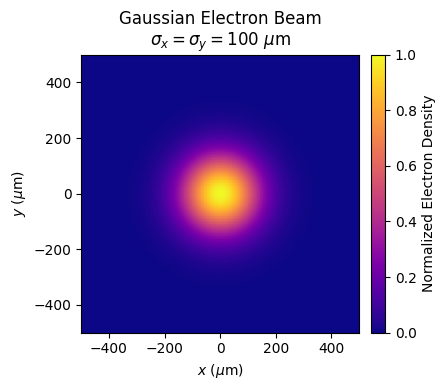

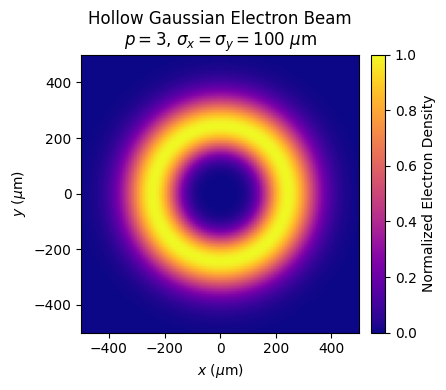

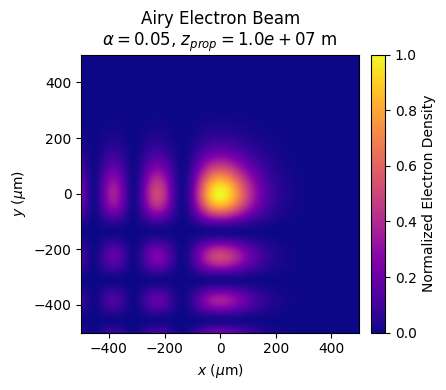

In [8]:
def plot_transverse_density(x, y, rho_xy, title):
    rho_xy = np.asarray(rho_xy, dtype=float)
    
    #Normalizing electron density
    rho_plot = rho_xy/np.max(rho_xy)

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(rho_plot.T,extent=[x.min()*1e6, x.max()*1e6, y.min()*1e6, y.max()*1e6], origin="lower", cmap="plasma", vmin=0, vmax=1, aspect="equal")
    ax.set_xlabel(r"$x$ ($\mu$m)")
    ax.set_ylabel(r"$y$ ($\mu$m)")
    ax.set_title(title)

    cbar = fig.colorbar(im, ax=ax, pad=0.03)
    cbar.set_label("Normalized Electron Density")

    plt.tight_layout()
    plt.show()


#Find the z=0 plane for the 3D distributions
iz0 = np.argmin(np.abs(z3d))

#Gaussian transverse density at z=0
plot_transverse_density(x3d, y3d, rho_gaussian[:, :, iz0], r"Gaussian Electron Beam" + "\n" + r"$\sigma_x=\sigma_y=100\ \mu\mathrm{m}$")

#Hollow-Gaussian transverse density at z=0
plot_transverse_density(x3d, y3d, rho_hollow[:, :, iz0], rf"Hollow Gaussian Electron Beam" + "\n" + rf"$p={p_hollow}$, $\sigma_x=\sigma_y=100\ \mu\mathrm{{m}}$")

#Airy density at the selected propagation plane
plot_transverse_density(x_airy, y_airy, rho_airy, r"Airy Electron Beam" + "\n" + rf"$\alpha={airy_apodization}$, $z_{{prop}}={z_prop:.1e}\ \mathrm{{m}}$")

## 5. Form factors

In [9]:
def _tilted_fourier_coordinates(omega, theta, phi, beta, psi):
    #Fourier coordinates used by the tilted-interface form factor model. Ref: M V Tsarev and P Baum 2018 New J. Phys. 20 033002 Section 2
    k = omega / c
    kx = k * np.sin(theta) * np.cos(phi)
    ky = k * np.sin(theta) * np.sin(phi)

    v = beta * c

    kx_target = (kx - (omega / v) * np.sin(psi)) / np.cos(psi)
    ky_target = ky
    kz_target = omega / v

    return kx_target, ky_target, kz_target


def f2_3d(omega, theta, phi, rho_xyz, x, y, z, beta, psi=np.deg2rad(45.0)):
    #Normalizing 3D density form factor
    omega = np.asarray(omega, dtype=float)
    theta = np.asarray(theta, dtype=float)
    phi = np.asarray(phi, dtype=float)
    rho_xyz = np.asarray(rho_xyz, dtype=float)

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)

    dx = x[1] - x[0]
    dy = y[1] - y[0]
    dz = z[1] - z[0]

    norm = np.trapezoid(np.trapezoid(np.trapezoid(rho_xyz, z, axis=2), y, axis=1), x, axis=0)

    rho_norm = rho_xyz/norm

    R = (np.fft.fftshift(np.fft.fftn(np.fft.ifftshift(rho_norm)))*dx*dy*dz)

    kx_grid = np.fft.fftshift(2.0 * np.pi * np.fft.fftfreq(len(x), d=dx))
    ky_grid = np.fft.fftshift(2.0 * np.pi * np.fft.fftfreq(len(y), d=dy))
    kz_grid = np.fft.fftshift(2.0 * np.pi * np.fft.fftfreq(len(z), d=dz))

    kx_target, ky_target, kz_target = _tilted_fourier_coordinates(omega, theta, phi, beta, psi)

    interp_real = RegularGridInterpolator((kx_grid, ky_grid, kz_grid), np.real(R), bounds_error=False, fill_value=0.0,)
    interp_imag = RegularGridInterpolator((kx_grid, ky_grid, kz_grid), np.imag(R), bounds_error=False, fill_value=0.0,)

    kx_target, ky_target, kz_target = np.broadcast_arrays(kx_target, ky_target, kz_target)

    points = np.column_stack([kx_target.ravel(), ky_target.ravel(), kz_target.ravel()])

    R_target = interp_real(points) + 1j * interp_imag(points)
    R_target = R_target.reshape(kx_target.shape)

    return np.abs(R_target)**2


def f2_2d(omega, theta, phi, rho_xy, x, y, beta, psi=np.deg2rad(45.0)):
    #Normalizing transverse 2D form factor
    omega = np.asarray(omega, dtype=float)
    theta = np.asarray(theta, dtype=float)
    phi = np.asarray(phi, dtype=float)
    rho_xy = np.asarray(rho_xy, dtype=float)

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    dx = x[1] - x[0]
    dy = y[1] - y[0]

    norm = np.trapezoid(np.trapezoid(rho_xy, y, axis=1), x, axis=0,)
    rho_norm = rho_xy/norm

    R = (np.fft.fftshift(np.fft.fftn(np.fft.ifftshift(rho_norm)))*dx*dy)

    kx_grid = np.fft.fftshift(2.0*np.pi*np.fft.fftfreq(len(x), d=dx))
    ky_grid = np.fft.fftshift(2.0*np.pi*np.fft.fftfreq(len(y), d=dy))

    kx_target, ky_target, _ = _tilted_fourier_coordinates(omega, theta, phi, beta, psi)

    interp_real = RegularGridInterpolator((kx_grid, ky_grid), np.real(R), bounds_error=False, fill_value=0.0)
    interp_imag = RegularGridInterpolator((kx_grid, ky_grid), np.imag(R), bounds_error=False, fill_value=0.0)

    kx_target, ky_target = np.broadcast_arrays(kx_target, ky_target)
    points = np.column_stack([kx_target.ravel(),ky_target.ravel()])
    R_target = interp_real(points) + 1j * interp_imag(points)
    R_target = R_target.reshape(kx_target.shape)

    return np.abs(R_target)**2


## 6. Select a bunch model and calculate its form factor

The Airy branch represents the Airy bunch using the **real, nonnegative transverse charge density**, $\rho_{\mathrm{Airy}} = |\psi_{\mathrm{Airy}}|^2$, and evaluates the corresponding **two-dimensional transverse form factor**. In contrast, the Gaussian and hollow-Gaussian branches are defined using the complete three-dimensional charge density and therefore employ the **full three-dimensional form factor**.

In [ ]:
if beam_case == "gaussian":
    F2 = f2_3d(OMEGA, TH, PHI, rho_gaussian, x3d, y3d, z3d, beta, psi=psi)
    spectrum_title = ("CTR: Gaussian Bunch" + "\n" + rf"$\tau={sigma_t:.1e}\ \mathrm{{s}}$")

elif beam_case == "hollow":
    F2 = f2_3d(OMEGA, TH, PHI, rho_hollow, x3d, y3d, z3d, beta, psi=psi)
    spectrum_title = ("CTR: Hollow Gaussian Bunch" + "\n" + rf"$p={p_hollow}$, $\tau={sigma_t:.1e}\ \mathrm{{s}}$")

elif beam_case == "airy":
    F2 = f2_2d(OMEGA, TH, PHI, rho_airy, x_airy, y_airy, beta, psi=psi)
    spectrum_title = ("CTR: Airy Bunch" + "\n" + rf"$\alpha={airy_apodization}$, " + rf"$z_{{prop}}={z_prop:.1e}\ \mathrm{{m}}$" + "\n" + rf"$\xi={xi:.2e}$")

else:
    raise ValueError('beam_case must be "gaussian", "hollow", or "airy"')


## 7. Coherent bunch spectrum

In [11]:
def electron_bunch_spectrum(W1, Ne, F2):
    #Applying coherent/incoherent bunch factor to single-electron spectrum
    Wn = W1 * (Ne + Ne * (Ne - 1.0) * F2)
    positive = Wn[Wn > 0]
    vmin = np.percentile(positive, 1) if positive.size else 1e-30
    vmax = np.max(Wn)
    return Wn, vmin, vmax

Wn, vmin, vmax = electron_bunch_spectrum(W1_tilted, Ne, F2,)


### Select a phi slice

In [12]:
# Phi slice for vizualisation 
phi_target = 0.0
iphi = np.argmin(np.abs(phi - phi_target))
Wn_phi0 = Wn[:, :, iphi]

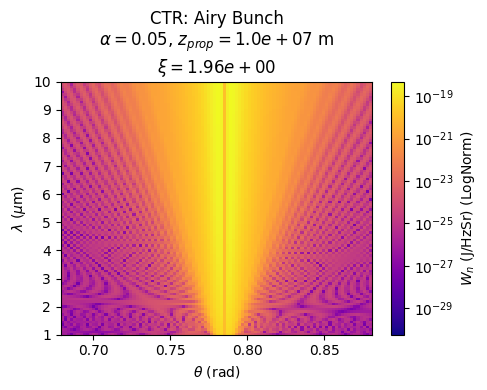

In [13]:
def plot_ctr_spectrum(th, lam, Wn_2d, title, vmin=None, vmax=None):
    Wn_2d = np.asarray(Wn_2d, dtype=float)

    positive = Wn_2d[Wn_2d > 0]

    if vmin is None:
        vmin = np.percentile(positive, 1) if positive.size else 1e-30
    if vmax is None:
        vmax = np.max(Wn_2d) if Wn_2d.size else vmin

    fig, ax = plt.subplots(figsize=(5, 4))

    im = ax.pcolormesh(th, lam*1e6, np.maximum(Wn_2d, vmin), shading="auto", cmap="plasma", norm=LogNorm(vmin=vmin, vmax=vmax), rasterized=True)
    ax.set_title(title)
    ax.set_xlabel(r"$\theta$ (rad)")
    ax.set_ylabel(r"$\lambda$ ($\mu$m)")
    ax.set_ylim(lam.min() * 1e6, lam.max() * 1e6)
    cb = fig.colorbar(im, ax=ax)
    cb.set_label(r"$W_n$ (J/HzSr) (LogNorm)")
    plt.tight_layout()
    plt.show()

plot_ctr_spectrum(th, lam, Wn_phi0, spectrum_title, vmin=vmin, vmax=vmax)


## 8. Longitudinal coherence

In [23]:
def plot_ctr_coherence_threshold(sigma_t_list, Ne = Ne, lam_min=1e-8, lam_max=1e-2, Nlam=10000, Nz=2**15, z_extent=12):
    lam = np.logspace(np.log10(lam_min), np.log10(lam_max), Nlam)
    omega = 2 * np.pi * c/lam
    lambda_coherent_list = []

    fig, ax = plt.subplots(figsize=(5, 4))

    for sigma_t in sigma_t_list:
        sigma_z = c * sigma_t
        z = np.linspace(-z_extent * sigma_z, z_extent * sigma_z, Nz)
        dz = z[1] - z[0]
        rho_z = np.exp(-0.5 * (z/sigma_z)**2)
        rho_z /= np.trapezoid(rho_z, z)
        R_z = (np.fft.fftshift(np.fft.fft(np.fft.ifftshift(rho_z)))*dz)
        kz = np.fft.fftshift(2 * np.pi * np.fft.fftfreq(Nz, d=dz))
        R_z /= R_z[np.argmin(np.abs(kz))]
        F2_k = np.abs(R_z)**2
        mask = kz >= 0
        kz_positive = kz[mask]
        F2_positive = F2_k[mask]
        k_target = omega / c

        #Interpolate FFT result onto wavelength grid
        F2_interp = interp1d(kz_positive, F2_positive, kind='linear', bounds_error=False, fill_value=0.0)
        F2 = F2_interp(k_target)
        ratio = (Ne - 1) * F2

        idx = np.argmin(np.abs(ratio - 1))
        lambda_coherent = lam[idx]
        lambda_coherent_list.append(lambda_coherent)
        line, = ax.loglog(lam * 1e6, ratio,label=(fr'$\sigma_t='fr'{sigma_t * 1e15:.0f}$ fs'))

        ax.axvline(lambda_coherent * 1e6, color=line.get_color(), linestyle='--', alpha=0.6)

    ax.axhline(1, linestyle='--', label=r'$W_{\rm coh}/W_{\rm incoh}=1$')
    annotation_y = np.logspace(7, 4, len(lambda_coherent_list))

    for lambda_coherent, y_pos in zip(lambda_coherent_list, annotation_y):
        ax.text(lambda_coherent * 1e6, y_pos, fr'$\lambda_c='fr'{lambda_coherent * 1e6:.2f}\ ' fr'\mu\mathrm{{m}}$', rotation=90, ha='right', va='top', fontsize=8)

    ax.set_xlabel(r'Wavelength $\lambda$ ($\mu$m)')
    ax.set_ylabel(r'$W_{\rm coh}/W_{\rm incoh}$')
    ax.set_title('CTR Longitudinal Coherence Threshold\n' + fr'$Q={bunchcharge * 1e12:.0f}$ pC')
    ax.set_ylim(1e-24, 1e10)
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return lambda_coherent_list, fig, ax

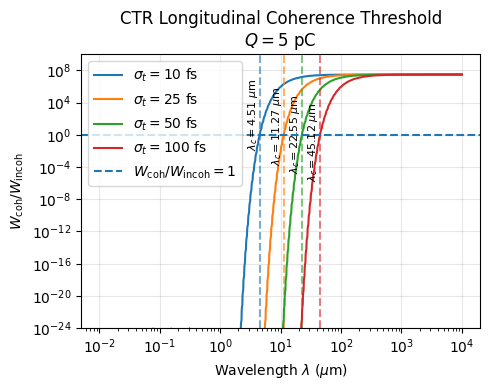

In [ ]:
sigma_t_list = [1e-14, 2.5e-14, 5e-14, 1e-13]
lambda_coherent_list, fig, ax = plot_ctr_coherence_threshold(sigma_t_list)

## 9. Optional finite-radiator radius scan

In [16]:
def finite_screen_TR(int_radius,wavelength,beta,gamma,theta_scan=None):
    #Optional diagonistic for normal interface finite screen. Ref: TESLA Report 2005-15. Section 3
    if int_radius == 0:
        return 0.0

    if theta_scan is None:
        theta_scan = np.linspace(0.0, np.pi/2.0, 100000)

    theta_scan = np.asarray(theta_scan, dtype=float)
    sin_theta = np.sin(theta_scan)
    cos_theta = np.cos(theta_scan)

    GF = (e**2/(4.0 * np.pi**3 * eps0 * c)(beta**2 * sin_theta**2/(1.0 - beta**2 * cos_theta**2)**2))

    omega = 2.0 * np.pi * c / wavelength
    u = omega * int_radius * sin_theta / c
    q = omega * int_radius / (c * beta * gamma)

    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        T1 = q * j0(u) * k1(q)
        J1_over_sin = np.divide(j1(u), sin_theta, out=np.zeros_like(theta_scan), where=np.abs(sin_theta) > 1e-14)
        J1_over_sin[np.abs(sin_theta) <= 1e-14] = (omega * int_radius / (2.0 * c))
        T2 = (omega * int_radius/(c * beta**2 * gamma**2) * J1_over_sin * k0(q))
        T = T1 + T2

    W = GF * np.abs(1.0 - T)**2

    dU_domega = 2.0 * np.pi * np.trapezoid(W * sin_theta, theta_scan)
    dU_dnu = 2.0 * np.pi * dU_domega

    return dU_dnu / e * 1e9


#Set True to run the optional radius scan. Ref: TESLA Report 2005-15. Section 3 Figure 5
RUN_FINITE_RADIATOR_SCAN = False

if RUN_FINITE_RADIATOR_SCAN:
    wavelengths = [100e-6, 300e-6, 1e-3, 3e-3]
    labels = [r"100 $\mu$m", r"300 $\mu$m", "1 mm", "3 mm"]

    a_mm = np.linspace(0.0, 20.0, 300)
    a_values = a_mm * 1e-3

    fig, ax = plt.subplots(figsize=(5, 4))

    for wavelength, label in zip(wavelengths, labels):
        curve = np.array(
            [
                finite_screen_TR(a_value, wavelength, beta, gamma)
                for a_value in a_values
            ]
        )
        ax.plot(a_mm, curve, label=label)

    ax.set_xlim(0, 20)
    ax.set_xlabel("a [mm]")
    ax.set_ylabel("eV / GHz")
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-7, -7))
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.show()
